# Prediksi Harga Pembukaan Saham dengan RNN dan LSTM
## Multi-Sektor Bursa Efek Indonesia (BEI) — 2020 hingga 2026

**Penulisan Ilmiah**  
*Program Studi Sistem Informasi / Informatika*

---

### Deskripsi Proyek
Notebook ini membangun model prediksi harga pembukaan (*open price*) saham  
menggunakan dua pendekatan *Deep Learning*:
- **Simple RNN** (Recurrent Neural Network)
- **LSTM** (Long Short-Term Memory)

Dataset mencakup **5 saham dari berbagai sektor** di Bursa Efek Indonesia (BEI)  
periode **Januari 2020 – Mei 2026**:

| No | Ticker | Emiten | Sektor |
|----|--------|--------|--------|
| 1 | BBCA.JK | Bank Central Asia | Perbankan |
| 2 | TLKM.JK | Telkom Indonesia | Telekomunikasi |
| 3 | ADRO.JK | Adaro Energy | Energi & Tambang |
| 4 | GOTO.JK | GoTo Gojek Tokopedia | Teknologi |
| 5 | BMRI.JK | Bank Mandiri | Perbankan |

---


## 1. Import Library

In [1]:
!pip install statsmodels


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import warnings
import time
import os
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.stattools import adfuller

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("=" * 50)
print("  Library berhasil diimpor!")
print("=" * 50)
print(f"  NumPy      : {np.__version__}")
print(f"  Pandas     : {pd.__version__}")
print(f"  TensorFlow : {tf.__version__}")
print("=" * 50)


  Library berhasil diimpor!
  NumPy      : 2.4.4
  Pandas     : 3.0.2
  TensorFlow : 2.21.0


## 2. Konfigurasi Global

In [3]:
# ============================================================
# KONFIGURASI — ubah parameter di sini sesuai kebutuhan
# ============================================================

SAHAM = {
    "BBCA.JK": "Bank Central Asia (Perbankan)",
    "TLKM.JK": "Telkom Indonesia (Telekomunikasi)",
    "ADRO.JK": "Adaro Energy (Energi/Tambang)",
    "GOTO.JK": "GoTo Gojek Tokopedia (Teknologi)",
    "BMRI.JK": "Bank Mandiri (Perbankan)",
}

DATA_DIR    = "dataset/"   # folder dataset CSV
TIME_STEP   = 60           # lookback window (hari)
SPLIT_RATIO = 0.8          # 80% latih, 20% validasi
EPOCHS_RNN  = 50
EPOCHS_LSTM = 50
BATCH_SIZE  = 32
RANDOM_SEED = 42

# Set random seed agar hasil reproducible
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Buat folder output
os.makedirs("hasil", exist_ok=True)
os.makedirs("saved_model", exist_ok=True)

print("Konfigurasi telah diset.")
print(f"  Time step    : {TIME_STEP} hari")
print(f"  Split ratio  : {int(SPLIT_RATIO*100)}% latih / {int((1-SPLIT_RATIO)*100)}% validasi")
print(f"  Epochs RNN   : {EPOCHS_RNN}")
print(f"  Epochs LSTM  : {EPOCHS_LSTM}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Random seed  : {RANDOM_SEED}")
print(f"  Folder hasil : hasil/")
print(f"  Folder model : saved_model/")

Konfigurasi telah diset.
  Time step    : 60 hari
  Split ratio  : 80% latih / 19% validasi
  Epochs RNN   : 50
  Epochs LSTM  : 50
  Batch size   : 32
  Random seed  : 42
  Folder hasil : hasil/
  Folder model : saved_model/


## 3. Memuat dan Mengeksplorasi Dataset

In [4]:
dataframes = {}

print("Memuat dataset...")
print("=" * 100)
print(f"{'Ticker':<12} {'Emiten':<45} {'Jumlah Baris':>12} {'Tanggal Awal':>14} {'Tanggal Akhir':>14} {'Missing':>8}")
print("-" * 100)

for ticker, nama in SAHAM.items():
    fname = os.path.join(DATA_DIR, ticker.replace('.', '_') + '.csv')
    
    df = pd.read_csv(fname, parse_dates=['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    
    # Validasi & pembersihan data
    missing_before = df.isnull().sum().sum()
    df = df.dropna()                  # hapus baris dengan nilai kosong
    df = df[df['Volume'] > 0]         # hapus hari tanpa transaksi
    df = df.reset_index(drop=True)
    
    dataframes[ticker] = df
    print(f"{ticker:<12} {nama:<45} {len(df):>12,} {str(df['Date'].iloc[0].date()):>14} {str(df['Date'].iloc[-1].date()):>14} {missing_before:>8}")

print("=" * 100)
print(f"\nTotal saham dimuat: {len(dataframes)}")

Memuat dataset...
Ticker       Emiten                                        Jumlah Baris   Tanggal Awal  Tanggal Akhir  Missing
----------------------------------------------------------------------------------------------------
BBCA.JK      Bank Central Asia (Perbankan)                        1,524     2020-01-02     2026-05-06        0
TLKM.JK      Telkom Indonesia (Telekomunikasi)                    1,525     2020-01-02     2026-05-06        0
ADRO.JK      Adaro Energy (Energi/Tambang)                        1,525     2020-01-02     2026-05-06        0
GOTO.JK      GoTo Gojek Tokopedia (Teknologi)                       967     2022-04-11     2026-05-06        0
BMRI.JK      Bank Mandiri (Perbankan)                             1,525     2020-01-02     2026-05-06        0

Total saham dimuat: 5


### 3.1 Statistik Deskriptif

In [5]:
for ticker, nama in SAHAM.items():
    df = dataframes[ticker]
    print(f"\n{'='*65}")
    print(f"  {ticker} — {nama}")
    print(f"{'='*65}")
    print(df[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))


  BBCA.JK — Bank Central Asia (Perbankan)
           Open      High       Low     Close        Volume
count   1524.00   1524.00   1524.00   1524.00  1.524000e+03
mean    7978.55   8053.84   7902.39   7975.03  9.985998e+07
std     1397.49   1398.29   1399.92   1400.71  7.959185e+07
min     4450.00   4800.00   4325.00   4430.00  1.065390e+07
25%     6775.00   6820.00   6703.75   6750.00  6.040800e+07
50%     8075.00   8175.00   8000.00   8075.00  8.207235e+07
75%     9050.00   9100.00   8975.00   9050.00  1.134950e+08
max    10900.00  10950.00  10775.00  10950.00  1.432993e+09

  TLKM.JK — Telkom Indonesia (Telekomunikasi)
          Open     High      Low    Close        Volume
count  1525.00  1525.00  1525.00  1525.00  1.525000e+03
mean   3491.37  3531.47  3445.35  3487.10  1.155301e+08
std     559.33   559.58   559.14   560.89  7.640655e+07
min    2050.00  2300.00  2050.00  2290.00  7.959900e+06
25%    3060.00  3100.00  3020.00  3050.00  6.900440e+07
50%    3460.00  3500.00  3410.00  

### 3.2 Visualisasi Harga Open Seluruh Saham

In [6]:
# Uji stasioneritas diperlukan untuk memahami karakteristik data time series
# H0: Data tidak stasioner | H1: Data stasioner
# Jika p-value < 0.05 → tolak H0 → data stasioner

print("UJI STASIONERITAS — Augmented Dickey-Fuller (ADF) Test")
print("=" * 65)
print(f"{'Ticker':<12} {'ADF Statistic':>16} {'p-value':>12} {'Status':>20}")
print("-" * 65)

for ticker, nama in SAHAM.items():
    df = dataframes[ticker]
    result = adfuller(df['Open'].dropna(), autolag='AIC')
    adf_stat = result[0]
    p_value  = result[1]
    status   = "Stasioner ✅" if p_value < 0.05 else "Tidak Stasioner ⚠️"
    print(f"{ticker:<12} {adf_stat:>16.4f} {p_value:>12.6f} {status:>20}")

print("=" * 65)
print("\nKeterangan:")
print("  p-value < 0.05 → Data STASIONER (pola konsisten, baik untuk prediksi)")
print("  p-value ≥ 0.05 → Data TIDAK STASIONER (perlu differencing atau normalisasi)")
print("\nCatatan: Normalisasi MinMaxScaler yang diterapkan pada preprocessing")
print("akan membantu menstabilkan skala data meskipun tidak stasioner.")

UJI STASIONERITAS — Augmented Dickey-Fuller (ADF) Test
Ticker          ADF Statistic      p-value               Status
-----------------------------------------------------------------


BBCA.JK               -1.2601     0.647234   Tidak Stasioner ⚠️
TLKM.JK               -1.9560     0.306178   Tidak Stasioner ⚠️
ADRO.JK               -1.7972     0.381839   Tidak Stasioner ⚠️
GOTO.JK               -1.4117     0.576644   Tidak Stasioner ⚠️
BMRI.JK               -1.2028     0.672385   Tidak Stasioner ⚠️

Keterangan:
  p-value < 0.05 → Data STASIONER (pola konsisten, baik untuk prediksi)
  p-value ≥ 0.05 → Data TIDAK STASIONER (perlu differencing atau normalisasi)

Catatan: Normalisasi MinMaxScaler yang diterapkan pada preprocessing
akan membantu menstabilkan skala data meskipun tidak stasioner.


### 3.3 Analisis Korelasi Antar Saham

MATRIKS KORELASI HARGA OPEN ANTAR SAHAM
         BBCA.JK  TLKM.JK  ADRO.JK  GOTO.JK  BMRI.JK
BBCA.JK    1.000   -0.254    0.227   -0.378    0.856
TLKM.JK   -0.254    1.000    0.406    0.660   -0.270
ADRO.JK    0.227    0.406    1.000    0.444    0.205
GOTO.JK   -0.378    0.660    0.444    1.000   -0.526
BMRI.JK    0.856   -0.270    0.205   -0.526    1.000

Keterangan:
  Nilai mendekati  1.0 → Korelasi positif kuat
  Nilai mendekati -1.0 → Korelasi negatif kuat
  Nilai mendekati  0.0 → Tidak berkorelasi


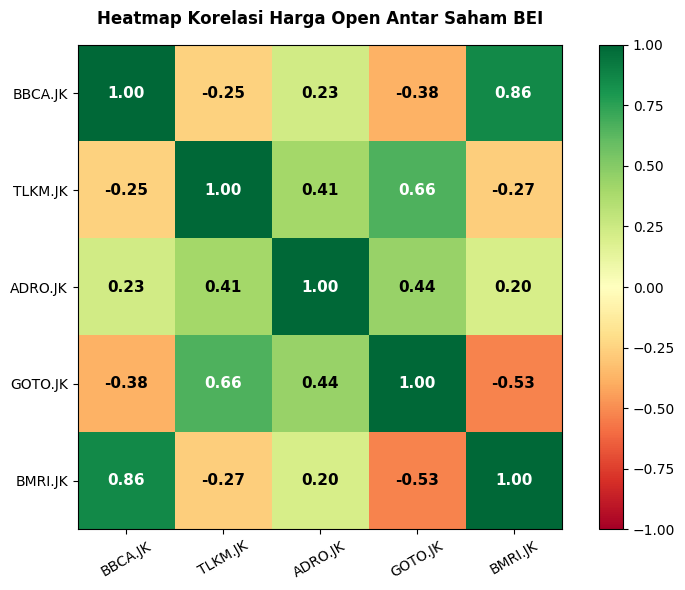

Grafik tersimpan di: hasil/00_korelasi_saham.png


In [7]:
# Melihat hubungan pergerakan harga antar saham lintas sektor
df_open_all = pd.DataFrame({
    ticker: dataframes[ticker].set_index('Date')['Open']
    for ticker in SAHAM
})

# Align index (ambil tanggal yang sama di semua saham)
df_open_all = df_open_all.dropna()
corr = df_open_all.corr().round(3)

print("MATRIKS KORELASI HARGA OPEN ANTAR SAHAM")
print("=" * 60)
print(corr)
print("\nKeterangan:")
print("  Nilai mendekati  1.0 → Korelasi positif kuat")
print("  Nilai mendekati -1.0 → Korelasi negatif kuat")
print("  Nilai mendekati  0.0 → Tidak berkorelasi")

# Heatmap korelasi
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
tickers = list(SAHAM.keys())
ax.set_xticks(range(len(tickers))); ax.set_xticklabels(tickers, rotation=30)
ax.set_yticks(range(len(tickers))); ax.set_yticklabels(tickers)
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if abs(corr.values[i,j]) > 0.6 else 'black')
ax.set_title('Heatmap Korelasi Harga Open Antar Saham BEI', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('hasil/00_korelasi_saham.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan di: hasil/00_korelasi_saham.png")

### 3.4 Visualisasi Harga Open dan Volume Seluruh Saham

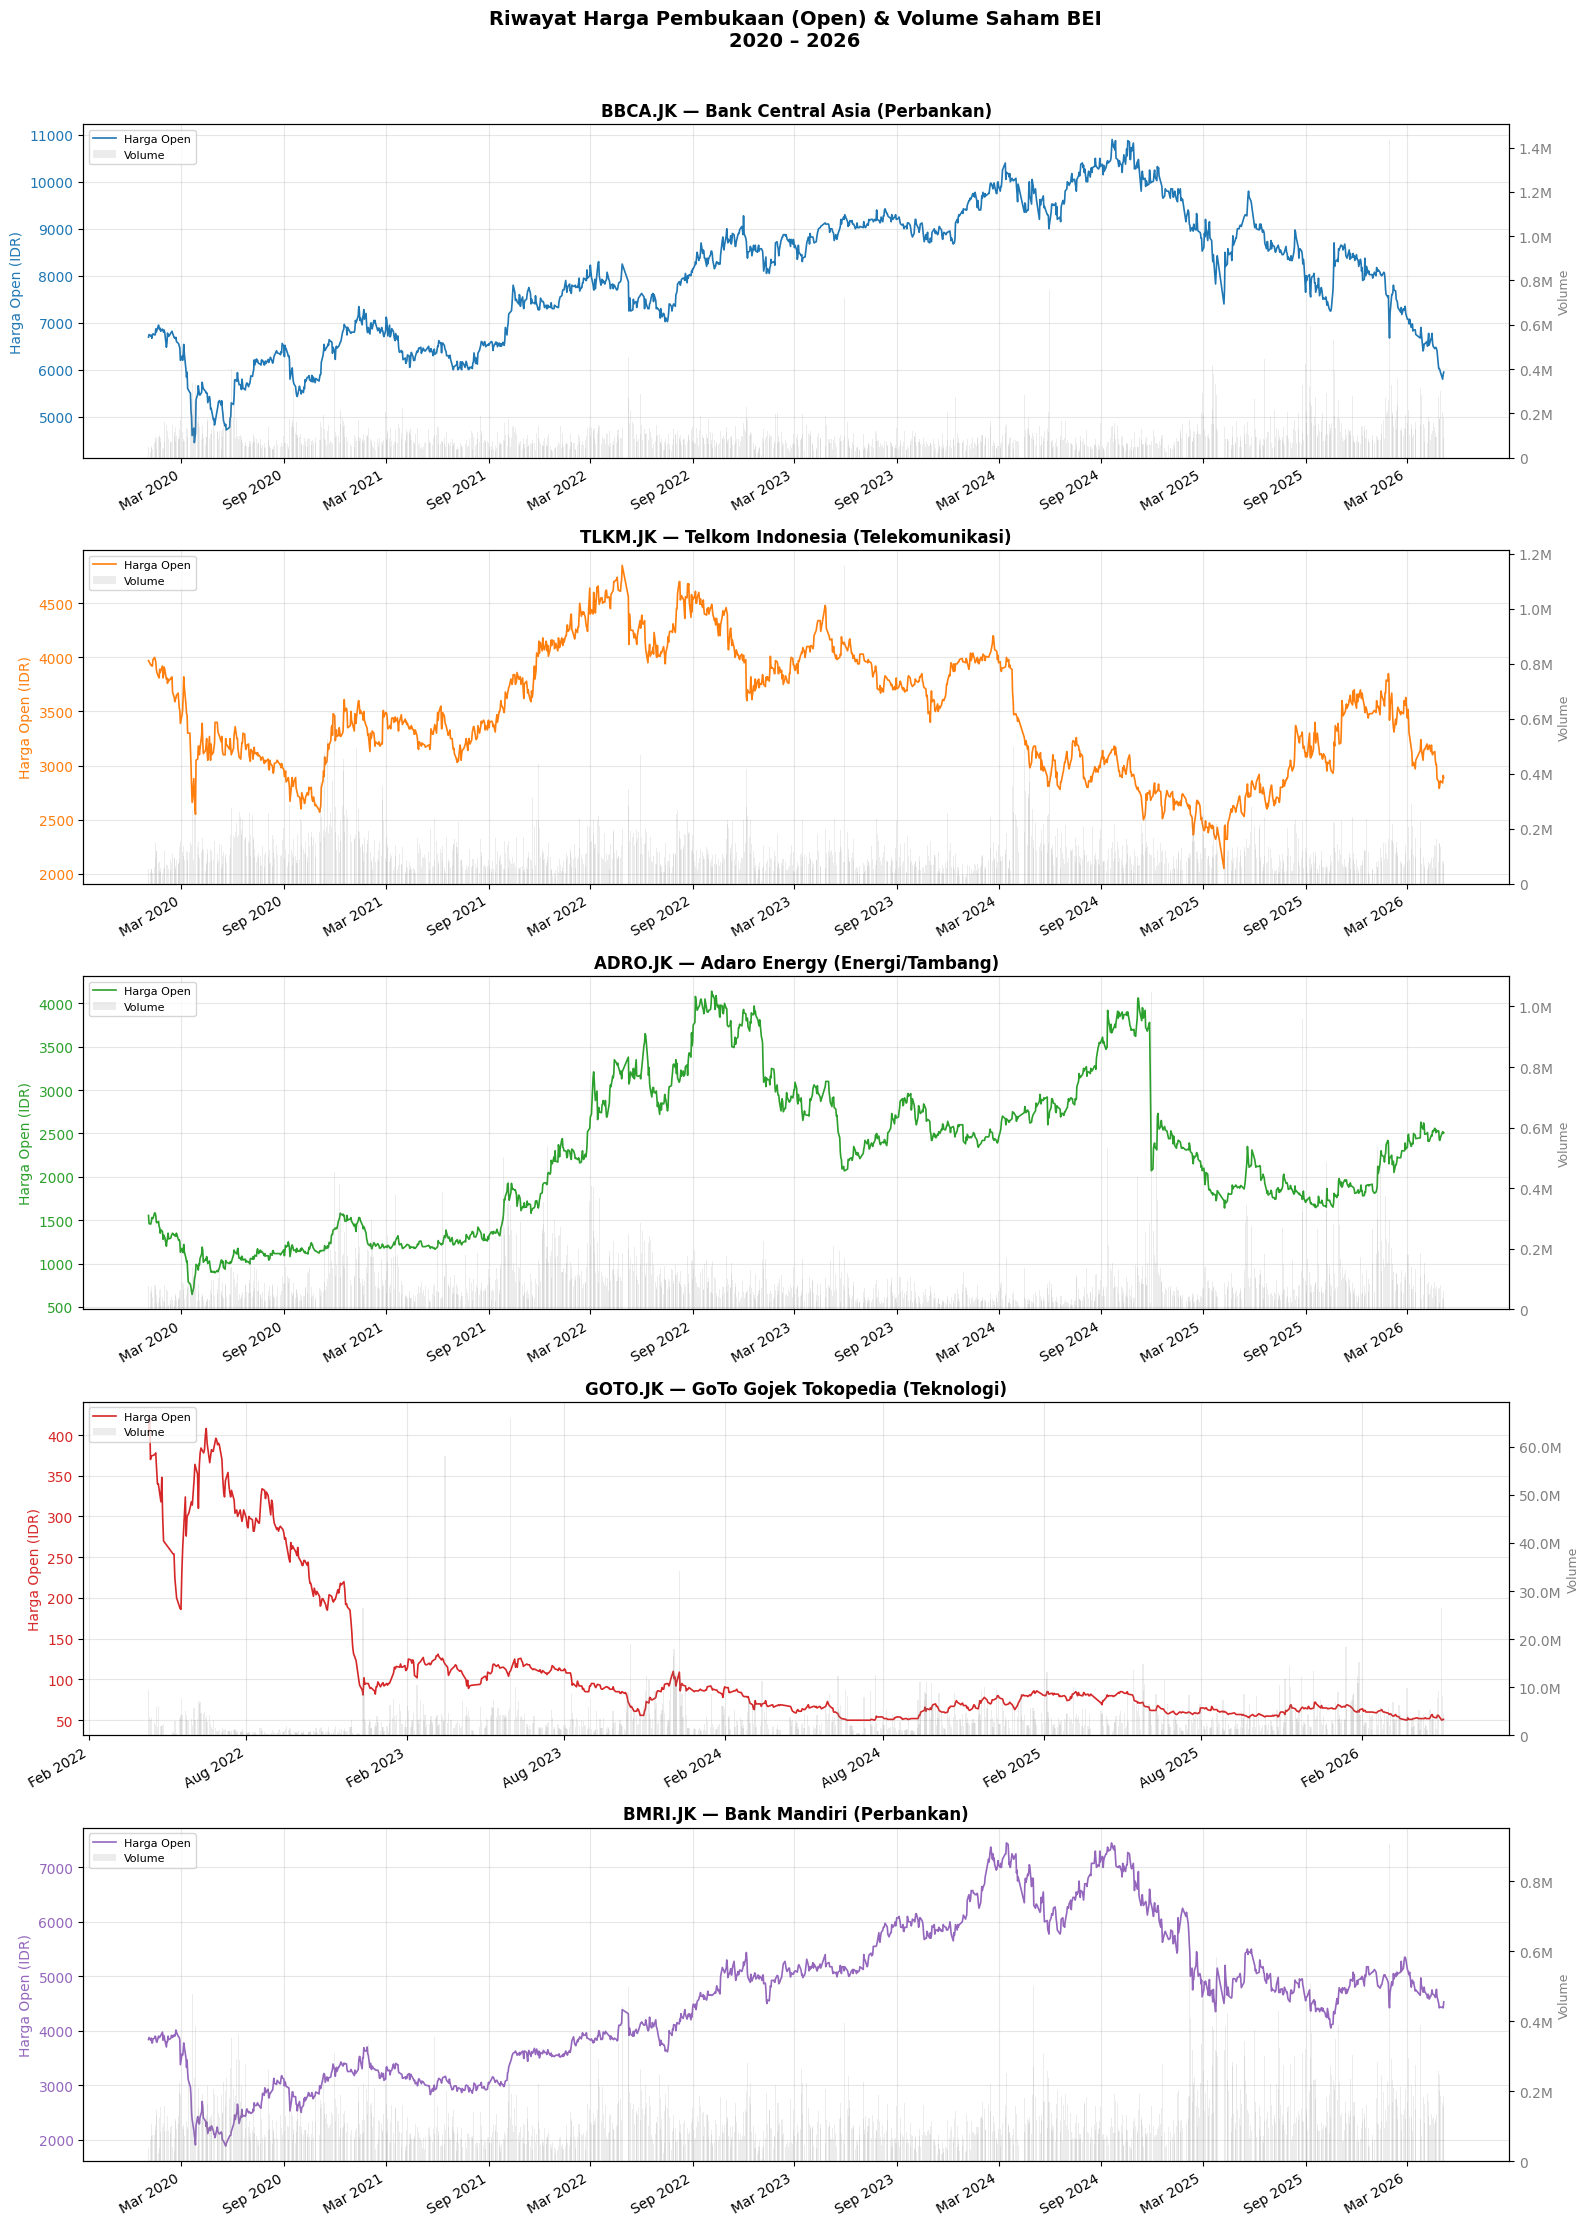

Grafik tersimpan di: hasil/01_harga_open_volume_semua_saham.png


In [8]:
fig, axes = plt.subplots(5, 1, figsize=(16, 22), sharex=False)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, (ticker, nama) in enumerate(SAHAM.items()):
    df = dataframes[ticker]
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # Plot harga Open
    ax1.plot(df['Date'], df['Open'], color=colors[i], linewidth=1.2, label='Harga Open', zorder=2)
    ax1.set_title(f'{ticker} — {nama}', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Harga Open (IDR)', fontsize=10, color=colors[i])
    ax1.tick_params(axis='y', labelcolor=colors[i])
    ax1.grid(True, alpha=0.3, zorder=1)

    # Plot Volume (bar transparan)
    ax2.bar(df['Date'], df['Volume'], alpha=0.15, color='gray', label='Volume', width=1.5)
    ax2.set_ylabel('Volume', fontsize=9, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e9:.1f}M' if x >= 1e6 else f'{x:.0f}'))

    # Legend gabungan
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')

plt.suptitle('Riwayat Harga Pembukaan (Open) & Volume Saham BEI\n2020 – 2026',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('hasil/01_harga_open_volume_semua_saham.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan di: hasil/01_harga_open_volume_semua_saham.png")

## 4. Baseline Model — Moving Average (Pembanding)

In [9]:
# Baseline diperlukan sebagai tolok ukur minimum yang harus dikalahkan model Deep Learning
# Menggunakan Moving Average 7 hari dan 30 hari

print("BASELINE MODEL — Moving Average")
print("=" * 70)
print(f"{'Ticker':<12} {'MA-7 RMSE':>12} {'MA-7 MAE':>12} {'MA-30 RMSE':>12} {'MA-30 MAE':>12}")
print("-" * 70)

baseline_results = {}
for ticker, nama in SAHAM.items():
    df = dataframes[ticker].copy()

    df['MA7']  = df['Open'].rolling(window=7).mean()
    df['MA30'] = df['Open'].rolling(window=30).mean()
    df_clean = df.dropna()

    actual = df_clean['Open'].values
    ma7    = df_clean['MA7'].values
    ma30   = df_clean['MA30'].values

    rmse_ma7  = np.sqrt(mean_squared_error(actual, ma7))
    mae_ma7   = mean_absolute_error(actual, ma7)
    rmse_ma30 = np.sqrt(mean_squared_error(actual, ma30))
    mae_ma30  = mean_absolute_error(actual, ma30)

    baseline_results[ticker] = {
        'rmse_ma7': rmse_ma7, 'mae_ma7': mae_ma7,
        'rmse_ma30': rmse_ma30, 'mae_ma30': mae_ma30
    }
    print(f"{ticker:<12} {rmse_ma7:>12,.2f} {mae_ma7:>12,.2f} {rmse_ma30:>12,.2f} {mae_ma30:>12,.2f}")

print("=" * 70)
print("\nTarget: Model RNN & LSTM harus menghasilkan RMSE & MAE lebih rendah dari baseline ini.")

BASELINE MODEL — Moving Average
Ticker          MA-7 RMSE     MA-7 MAE   MA-30 RMSE    MA-30 MAE
----------------------------------------------------------------------
BBCA.JK            159.38       116.21       321.55       249.37
TLKM.JK             85.11        63.36       173.55       134.05
ADRO.JK             98.10        60.82       213.00       143.53
GOTO.JK              7.01         4.01        19.26        11.07
BMRI.JK            123.53        88.60       259.04       195.11

Target: Model RNN & LSTM harus menghasilkan RMSE & MAE lebih rendah dari baseline ini.


## 5. Pra-Pemrosesan Data (*Preprocessing*)

In [10]:
def preprocess(df, time_step=TIME_STEP, split_ratio=SPLIT_RATIO):
    """
    Mempersiapkan data untuk pelatihan model:
    1. Ambil kolom 'Open'
    2. Normalisasi MinMaxScaler [0,1]
    3. Bagi menjadi data latih & validasi secara kronologis
    4. Buat sliding window X dan label y
    """
    series = df['Open'].values.reshape(-1, 1)

    # Normalisasi ke [0, 1]
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(series)

    n_total = len(scaled)
    n_train = int(n_total * split_ratio)

    train_scaled = scaled[:n_train]
    valid_scaled = scaled[n_train:]

    def make_xy(data, ts):
        X, y = [], []
        for i in range(ts, len(data)):
            X.append(data[i - ts:i, 0])
            y.append(data[i, 0])
        return np.array(X), np.array(y)

    X_train, y_train = make_xy(train_scaled, time_step)
    X_valid, y_valid = make_xy(valid_scaled, time_step)

    # Reshape ke 3D [samples, timesteps, features]
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_valid = X_valid.reshape(X_valid.shape[0], X_valid.shape[1], 1)
    y_train = y_train.reshape(-1, 1)
    y_valid = y_valid.reshape(-1, 1)

    return X_train, y_train, X_valid, y_valid, scaler, n_train

# Proses semua saham
preprocessed = {}
print("Hasil Preprocessing:")
print("=" * 75)
print(f"{'Ticker':<12} {'X_train':>15} {'y_train':>12} {'X_valid':>15} {'y_valid':>12}")
print("-" * 75)
for ticker in SAHAM:
    df = dataframes[ticker]
    result = preprocess(df)
    preprocessed[ticker] = result
    X_tr, y_tr, X_v, y_v, scaler, n_tr = result
    print(f"{ticker:<12} {str(X_tr.shape):>15} {str(y_tr.shape):>12} {str(X_v.shape):>15} {str(y_v.shape):>12}")
print("=" * 75)

Hasil Preprocessing:
Ticker               X_train      y_train         X_valid      y_valid
---------------------------------------------------------------------------
BBCA.JK        (1159, 60, 1)    (1159, 1)    (245, 60, 1)     (245, 1)
TLKM.JK        (1160, 60, 1)    (1160, 1)    (245, 60, 1)     (245, 1)
ADRO.JK        (1160, 60, 1)    (1160, 1)    (245, 60, 1)     (245, 1)
GOTO.JK         (713, 60, 1)     (713, 1)    (134, 60, 1)     (134, 1)
BMRI.JK        (1160, 60, 1)    (1160, 1)    (245, 60, 1)     (245, 1)


## 6. Arsitektur Model

### 6.1 Model Simple RNN

In [11]:
def build_rnn(input_shape):
    """
    Arsitektur Simple RNN:
    - Layer 1 & 2 : SimpleRNN 64 unit, return_sequences=True
    - Layer 3 & 4 : SimpleRNN 32 unit
    - Dropout 0.2 setelah setiap layer (cegah overfitting)
    - Output     : Dense 1 neuron (prediksi harga)
    - Optimizer  : Adam
    - Loss       : Mean Squared Error (MSE)
    """
    model = Sequential([
        SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        SimpleRNN(64, activation='tanh', return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32, activation='tanh', return_sequences=True),
        Dropout(0.2),
        SimpleRNN(32, activation='tanh'),
        Dropout(0.2),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

# Tampilkan ringkasan arsitektur
X_tr_sample, _, _, _, _, _ = preprocessed['BBCA.JK']
rnn_sample = build_rnn((X_tr_sample.shape[1], 1))
print("Arsitektur Simple RNN:")
rnn_sample.summary()

Arsitektur Simple RNN:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 60, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 60, 32)         │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,697 (69.13 KB)

 Trainable params: 17,697 (69.13 KB)

 Non-trainable params: 0 (0.00 B)

### 6.2 Model LSTM

In [12]:
def build_lstm(input_shape):
    """
    Arsitektur LSTM:
    - Layer 1 : LSTM 64 unit, return_sequences=True
    - Layer 2 : LSTM 64 unit
    - Dropout 0.2 setelah setiap LSTM layer
    - Dense 32 unit (ReLU) sebagai fully connected layer
    - Output  : Dense 1 neuron (prediksi harga)
    - Optimizer : Adam
    - Loss      : Mean Squared Error (MSE)
    """
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
    return model

# Tampilkan ringkasan arsitektur
lstm_sample = build_lstm((X_tr_sample.shape[1], 1))
print("Arsitektur LSTM:")
lstm_sample.summary()

Arsitektur LSTM:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,033 (203.25 KB)

 Trainable params: 52,033 (203.25 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Pelatihan dan Evaluasi Model

Pelatihan dilakukan untuk **setiap saham** menggunakan:
- `EarlyStopping` dengan `patience=10` untuk mencegah overfitting
- Metrik evaluasi: **RMSE**, **MAE**, **MAPE**, dan **R²**
- Pencatatan **durasi training** setiap model

In [13]:
def hitung_metrik(y_true, y_pred, scaler):
    """Menghitung RMSE, MAE, MAPE, dan R² pada skala harga asli (IDR)"""
    y_true_inv = scaler.inverse_transform(y_true)
    y_pred_inv = scaler.inverse_transform(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    mae  = mean_absolute_error(y_true_inv, y_pred_inv)
    mape = np.mean(np.abs((y_true_inv - y_pred_inv) / (y_true_inv + 1e-8))) * 100
    r2   = r2_score(y_true_inv, y_pred_inv)
    return rmse, mae, mape, r2

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=0
)

hasil_semua  = {}
waktu_training = {}

for ticker, nama in SAHAM.items():
    print(f"\n{'='*65}")
    print(f"  Melatih model untuk: {ticker} — {nama}")
    print(f"{'='*65}")

    X_tr, y_tr, X_v, y_v, scaler, n_train = preprocessed[ticker]
    input_shape = (X_tr.shape[1], 1)

    # ---- Simple RNN ----
    print("\n[1/2] Melatih Simple RNN...")
    rnn = build_rnn(input_shape)
    t0  = time.time()
    hist_rnn = rnn.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS_RNN,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )
    dur_rnn = time.time() - t0
    y_pred_rnn_train = rnn.predict(X_tr, verbose=0)
    y_pred_rnn_valid = rnn.predict(X_v,  verbose=0)
    rmse_rnn, mae_rnn, mape_rnn, r2_rnn = hitung_metrik(y_v, y_pred_rnn_valid, scaler)
    epoch_rnn = len(hist_rnn.history['loss'])
    print(f"    Epoch selesai : {epoch_rnn}/{EPOCHS_RNN}")
    print(f"    Durasi        : {dur_rnn:.1f} detik")
    print(f"    RMSE  : {rmse_rnn:,.2f} | MAE: {mae_rnn:,.2f} | MAPE: {mape_rnn:.2f}% | R²: {r2_rnn:.4f}")

    # ---- LSTM ----
    print("\n[2/2] Melatih LSTM...")
    lstm = build_lstm(input_shape)
    t0   = time.time()
    hist_lstm = lstm.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=EPOCHS_LSTM,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=0
    )
    dur_lstm = time.time() - t0
    y_pred_lstm_train = lstm.predict(X_tr, verbose=0)
    y_pred_lstm_valid = lstm.predict(X_v,  verbose=0)
    rmse_lstm, mae_lstm, mape_lstm, r2_lstm = hitung_metrik(y_v, y_pred_lstm_valid, scaler)
    epoch_lstm = len(hist_lstm.history['loss'])
    print(f"    Epoch selesai : {epoch_lstm}/{EPOCHS_LSTM}")
    print(f"    Durasi        : {dur_lstm:.1f} detik")
    print(f"    RMSE  : {rmse_lstm:,.2f} | MAE: {mae_lstm:,.2f} | MAPE: {mape_lstm:.2f}% | R²: {r2_lstm:.4f}")

    # Simpan model
    rnn.save(f"saved_model/rnn_{ticker.replace('.','_')}.h5")
    lstm.save(f"saved_model/lstm_{ticker.replace('.','_')}.h5")
    print(f"\n  ✅ Model tersimpan di saved_model/")

    hasil_semua[ticker] = {
        'rnn': rnn, 'lstm': lstm,
        'hist_rnn': hist_rnn, 'hist_lstm': hist_lstm,
        'X_tr': X_tr, 'y_tr': y_tr, 'X_v': X_v, 'y_v': y_v,
        'scaler': scaler, 'n_train': n_train,
        'y_pred_rnn_train':  y_pred_rnn_train,
        'y_pred_rnn_valid':  y_pred_rnn_valid,
        'y_pred_lstm_train': y_pred_lstm_train,
        'y_pred_lstm_valid': y_pred_lstm_valid,
        'metrik_rnn':  (rmse_rnn,  mae_rnn,  mape_rnn,  r2_rnn),
        'metrik_lstm': (rmse_lstm, mae_lstm, mape_lstm, r2_lstm),
        'epoch_rnn': epoch_rnn, 'epoch_lstm': epoch_lstm,
        'dur_rnn': dur_rnn, 'dur_lstm': dur_lstm,
    }

print("\n" + "="*65)
print("  ✅ Semua model berhasil dilatih dan disimpan!")
print("="*65)


  Melatih model untuk: BBCA.JK — Bank Central Asia (Perbankan)

[1/2] Melatih Simple RNN...
    Epoch selesai : 17/50
    Durasi        : 31.5 detik
    RMSE  : 277.74 | MAE: 197.79 | MAPE: 2.55% | R²: 0.8905

[2/2] Melatih LSTM...


    Epoch selesai : 10/50
    Durasi        : 24.6 detik
    RMSE  : 353.15 | MAE: 261.67 | MAPE: 3.31% | R²: 0.8230

  ✅ Model tersimpan di saved_model/

  Melatih model untuk: TLKM.JK — Telkom Indonesia (Telekomunikasi)

[1/2] Melatih Simple RNN...
    Epoch selesai : 10/50
    Durasi        : 20.9 detik
    RMSE  : 385.51 | MAE: 349.49 | MAPE: 11.61% | R²: -0.3281

[2/2] Melatih LSTM...


    Epoch selesai : 10/50
    Durasi        : 24.0 detik
    RMSE  : 177.62 | MAE: 148.00 | MAPE: 4.86% | R²: 0.7181

  ✅ Model tersimpan di saved_model/

  Melatih model untuk: ADRO.JK — Adaro Energy (Energi/Tambang)

[1/2] Melatih Simple RNN...
    Epoch selesai : 19/50
    Durasi        : 32.8 detik
    RMSE  : 102.84 | MAE: 76.16 | MAPE: 3.79% | R²: 0.8575

[2/2] Melatih LSTM...


    Epoch selesai : 38/50
    Durasi        : 77.9 detik
    RMSE  : 83.72 | MAE: 64.46 | MAPE: 3.19% | R²: 0.9056

  ✅ Model tersimpan di saved_model/

  Melatih model untuk: GOTO.JK — GoTo Gojek Tokopedia (Teknologi)

[1/2] Melatih Simple RNN...
    Epoch selesai : 11/50
    Durasi        : 16.4 detik
    RMSE  : 5.47 | MAE: 4.53 | MAPE: 7.59% | R²: 0.0486

[2/2] Melatih LSTM...


    Epoch selesai : 18/50
    Durasi        : 25.8 detik
    RMSE  : 2.75 | MAE: 2.15 | MAPE: 3.60% | R²: 0.7591

  ✅ Model tersimpan di saved_model/

  Melatih model untuk: BMRI.JK — Bank Mandiri (Perbankan)

[1/2] Melatih Simple RNN...
    Epoch selesai : 10/50
    Durasi        : 20.0 detik
    RMSE  : 481.39 | MAE: 449.26 | MAPE: 9.28% | R²: -1.8929

[2/2] Melatih LSTM...


    Epoch selesai : 10/50
    Durasi        : 22.7 detik
    RMSE  : 208.88 | MAE: 165.71 | MAPE: 3.39% | R²: 0.4554

  ✅ Model tersimpan di saved_model/

  ✅ Semua model berhasil dilatih dan disimpan!


## 8. Visualisasi Loss Pelatihan

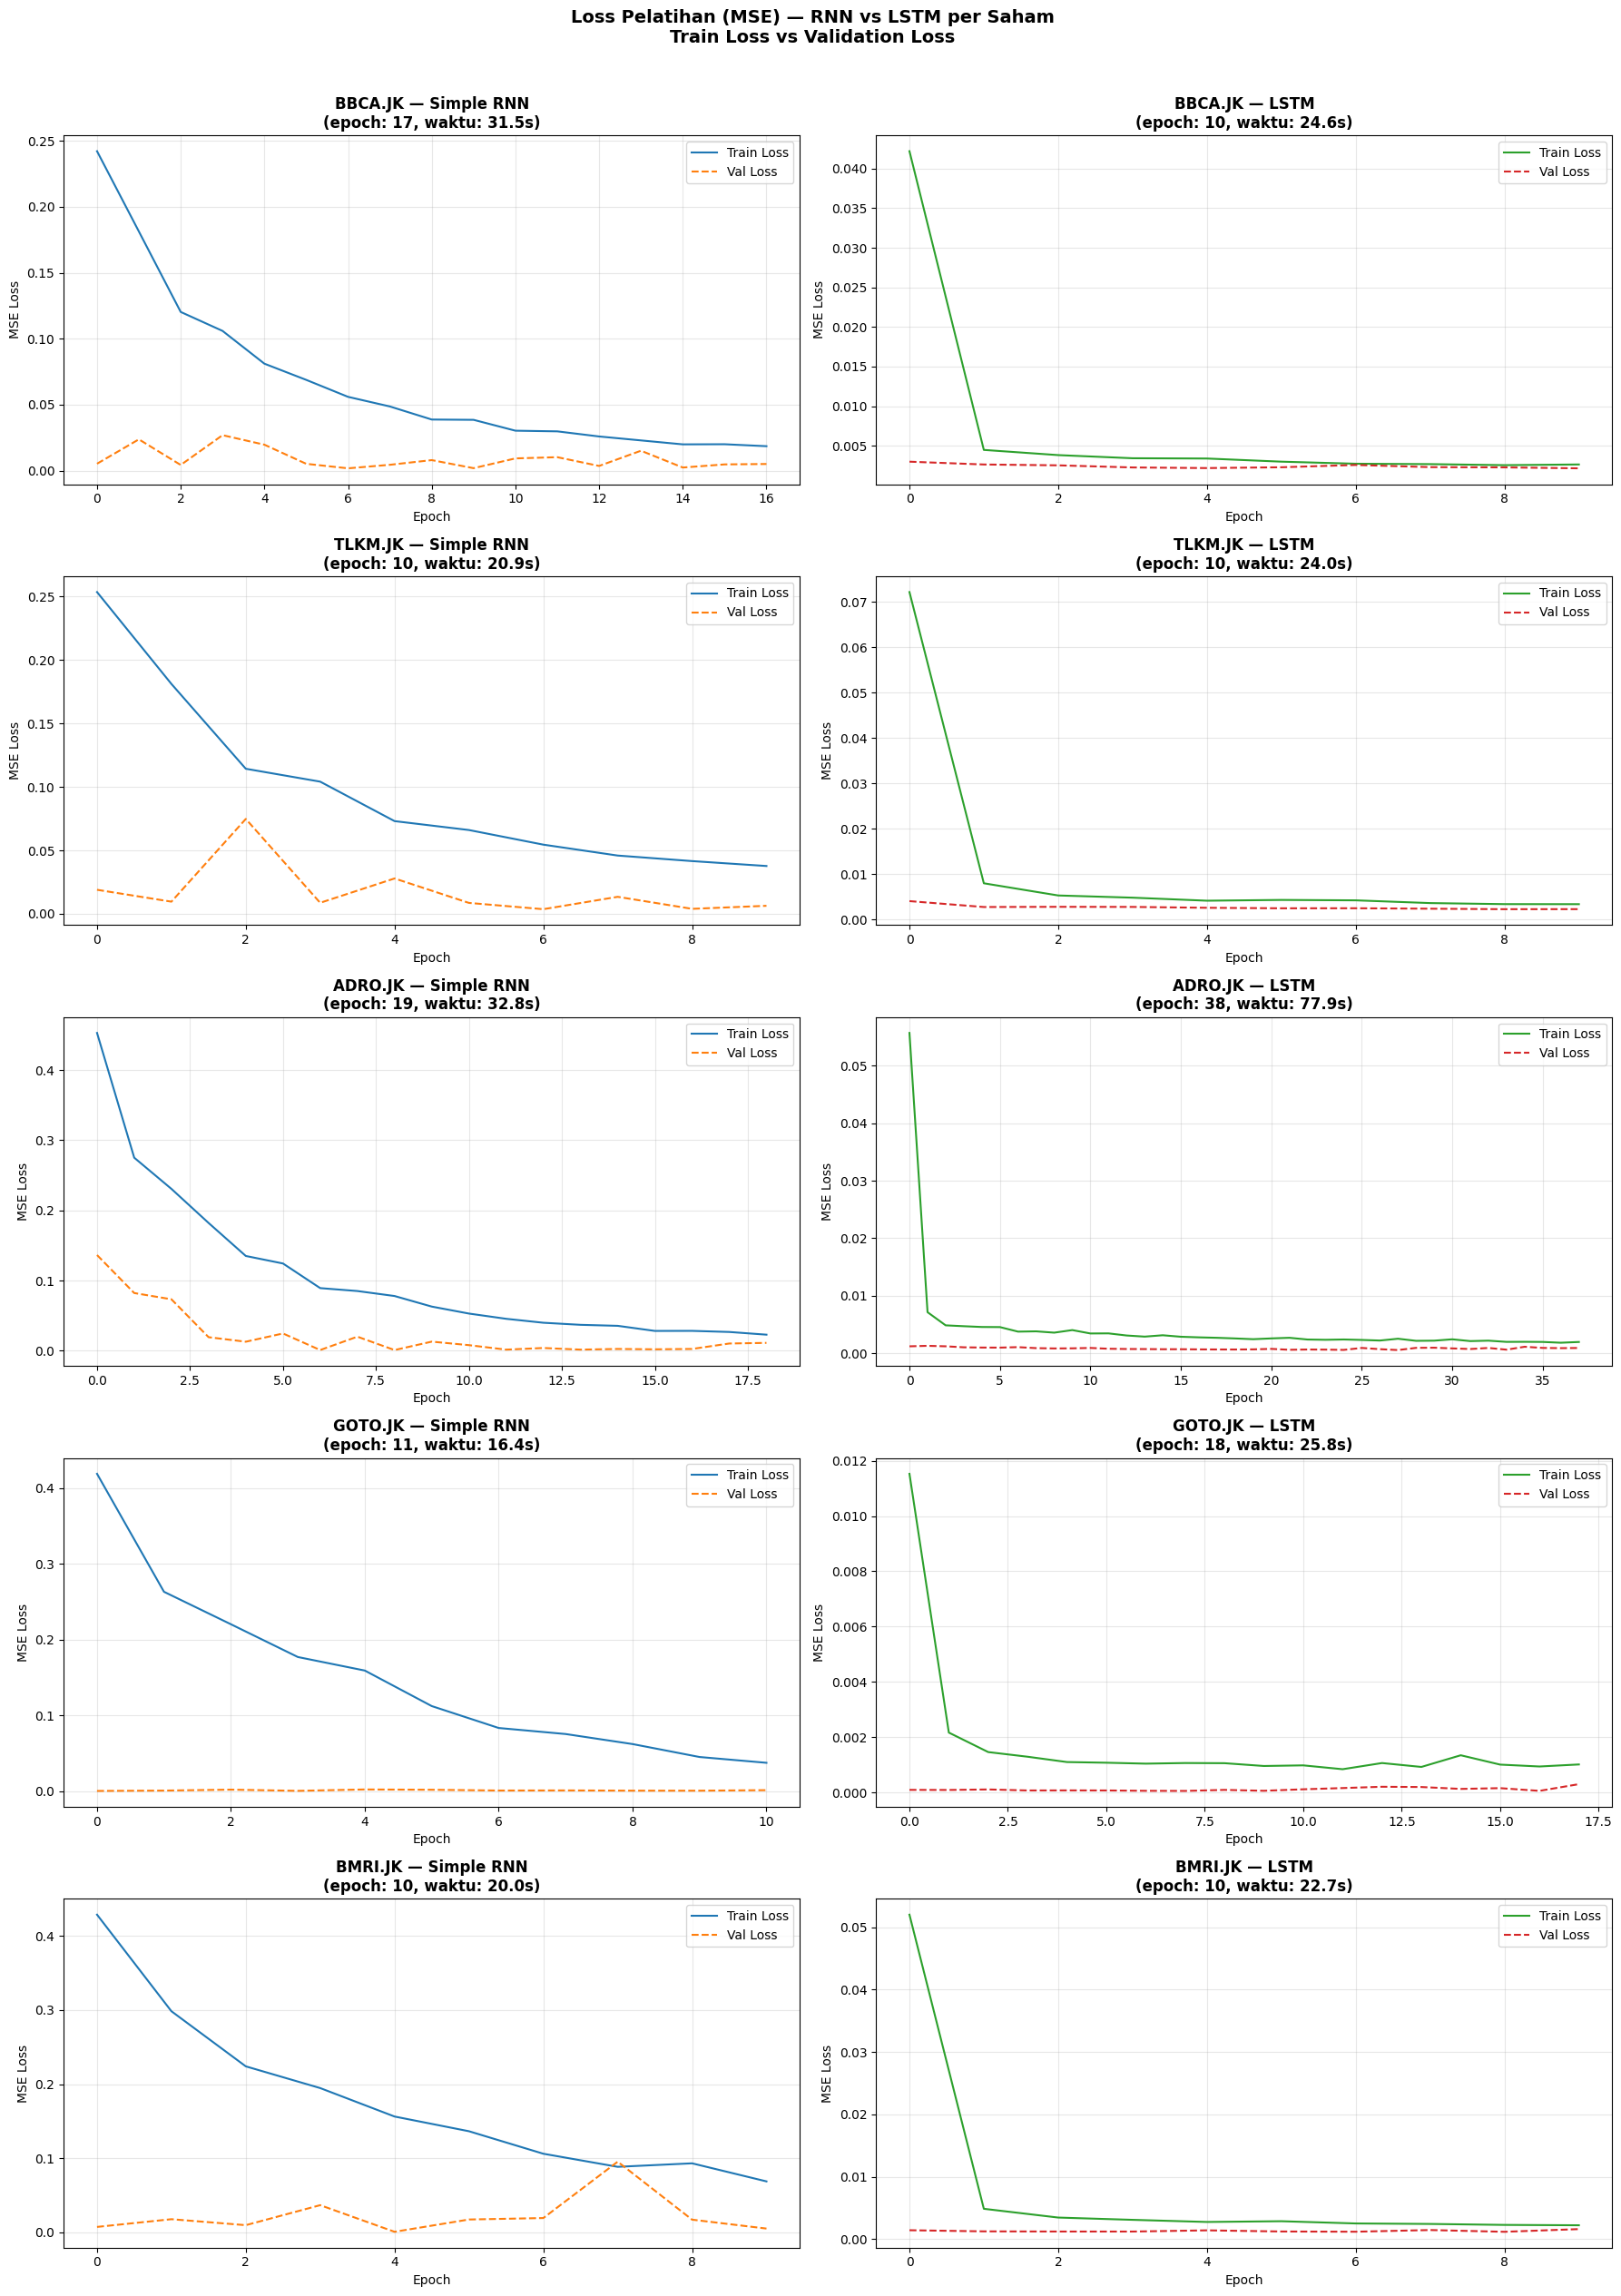

Grafik tersimpan di: hasil/02_loss_training.png


In [14]:
fig, axes = plt.subplots(5, 2, figsize=(18, 25))
fig.suptitle('Loss Pelatihan (MSE) — RNN vs LSTM per Saham\nTrain Loss vs Validation Loss',
             fontsize=14, fontweight='bold', y=1.01)

for i, (ticker, nama) in enumerate(SAHAM.items()):
    h = hasil_semua[ticker]

    # RNN loss
    axes[i, 0].plot(h['hist_rnn'].history['loss'],     label='Train Loss', color='#1f77b4', linewidth=1.5)
    axes[i, 0].plot(h['hist_rnn'].history['val_loss'], label='Val Loss',   color='#ff7f0e', linewidth=1.5, linestyle='--')
    axes[i, 0].set_title(f"{ticker} — Simple RNN\n(epoch: {h['epoch_rnn']}, waktu: {h['dur_rnn']:.1f}s)", fontweight='bold')
    axes[i, 0].set_xlabel('Epoch')
    axes[i, 0].set_ylabel('MSE Loss')
    axes[i, 0].legend()
    axes[i, 0].grid(True, alpha=0.3)

    # LSTM loss
    axes[i, 1].plot(h['hist_lstm'].history['loss'],     label='Train Loss', color='#2ca02c', linewidth=1.5)
    axes[i, 1].plot(h['hist_lstm'].history['val_loss'], label='Val Loss',   color='#d62728', linewidth=1.5, linestyle='--')
    axes[i, 1].set_title(f"{ticker} — LSTM\n(epoch: {h['epoch_lstm']}, waktu: {h['dur_lstm']:.1f}s)", fontweight='bold')
    axes[i, 1].set_xlabel('Epoch')
    axes[i, 1].set_ylabel('MSE Loss')
    axes[i, 1].legend()
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hasil/02_loss_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan di: hasil/02_loss_training.png")

## 9. Visualisasi Prediksi vs Data Aktual

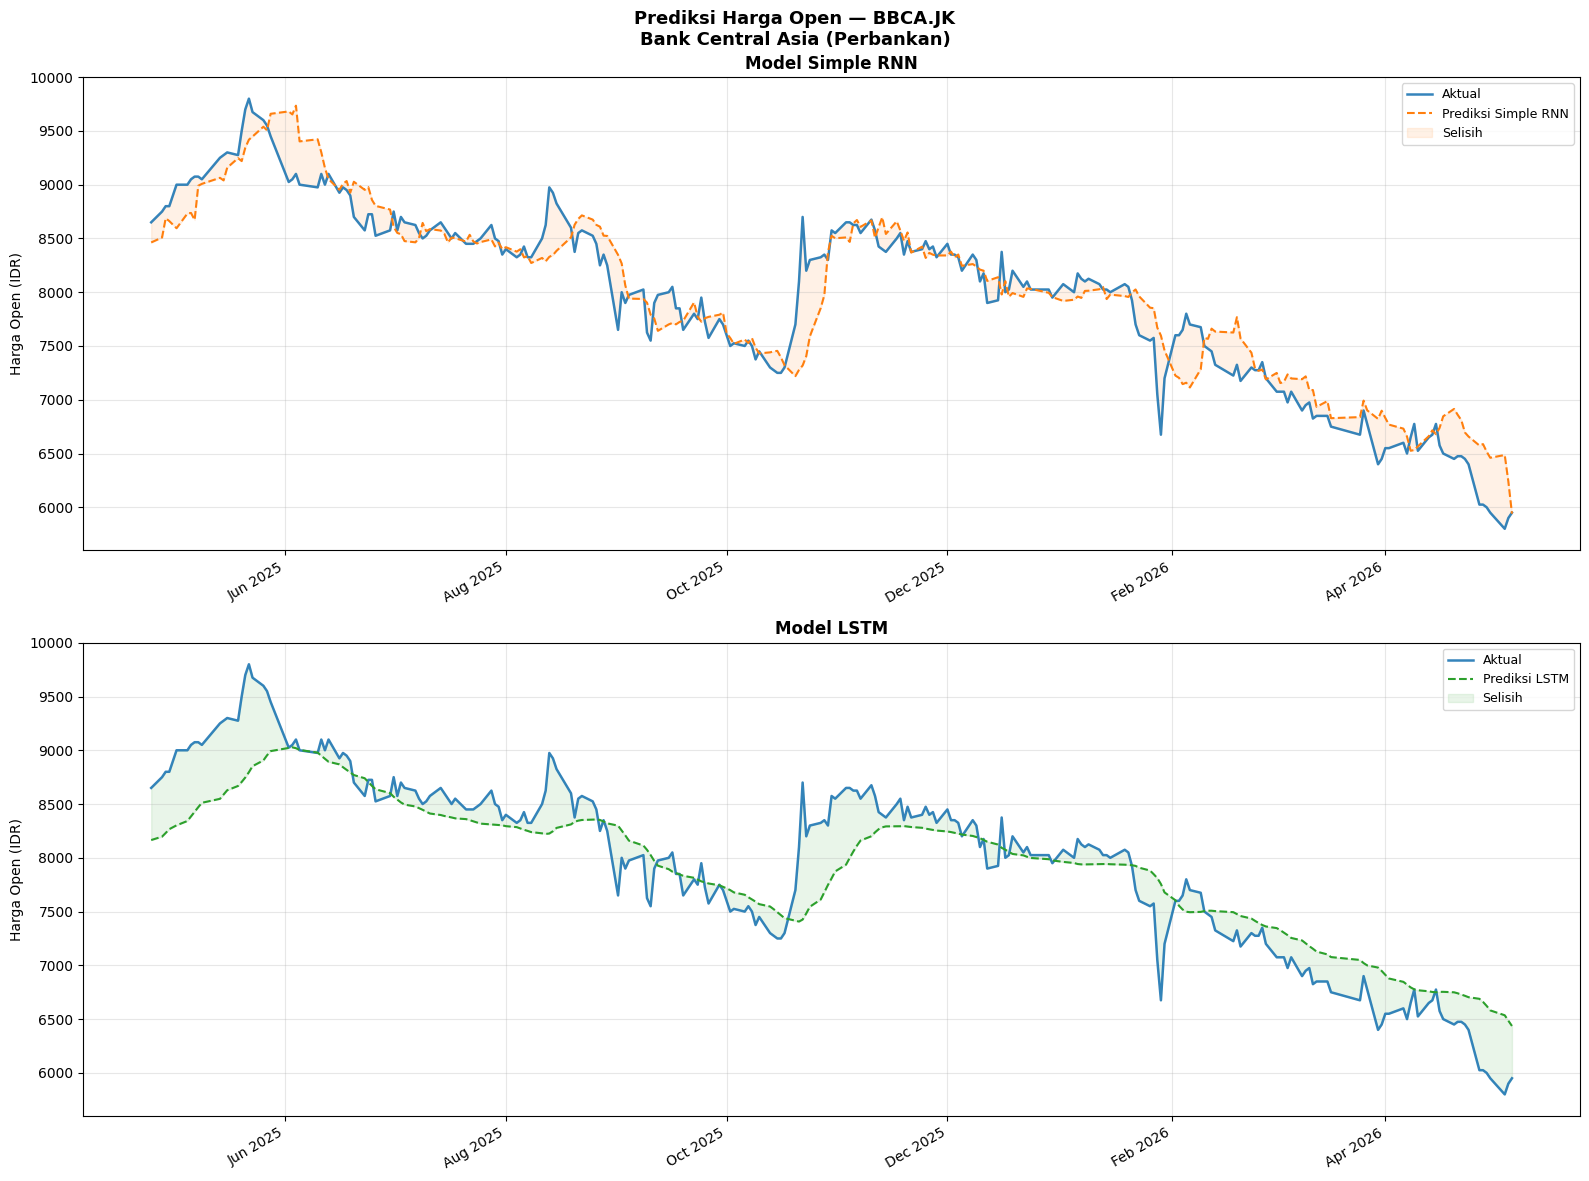

  Tersimpan: hasil/03_prediksi_BBCA_JK.png


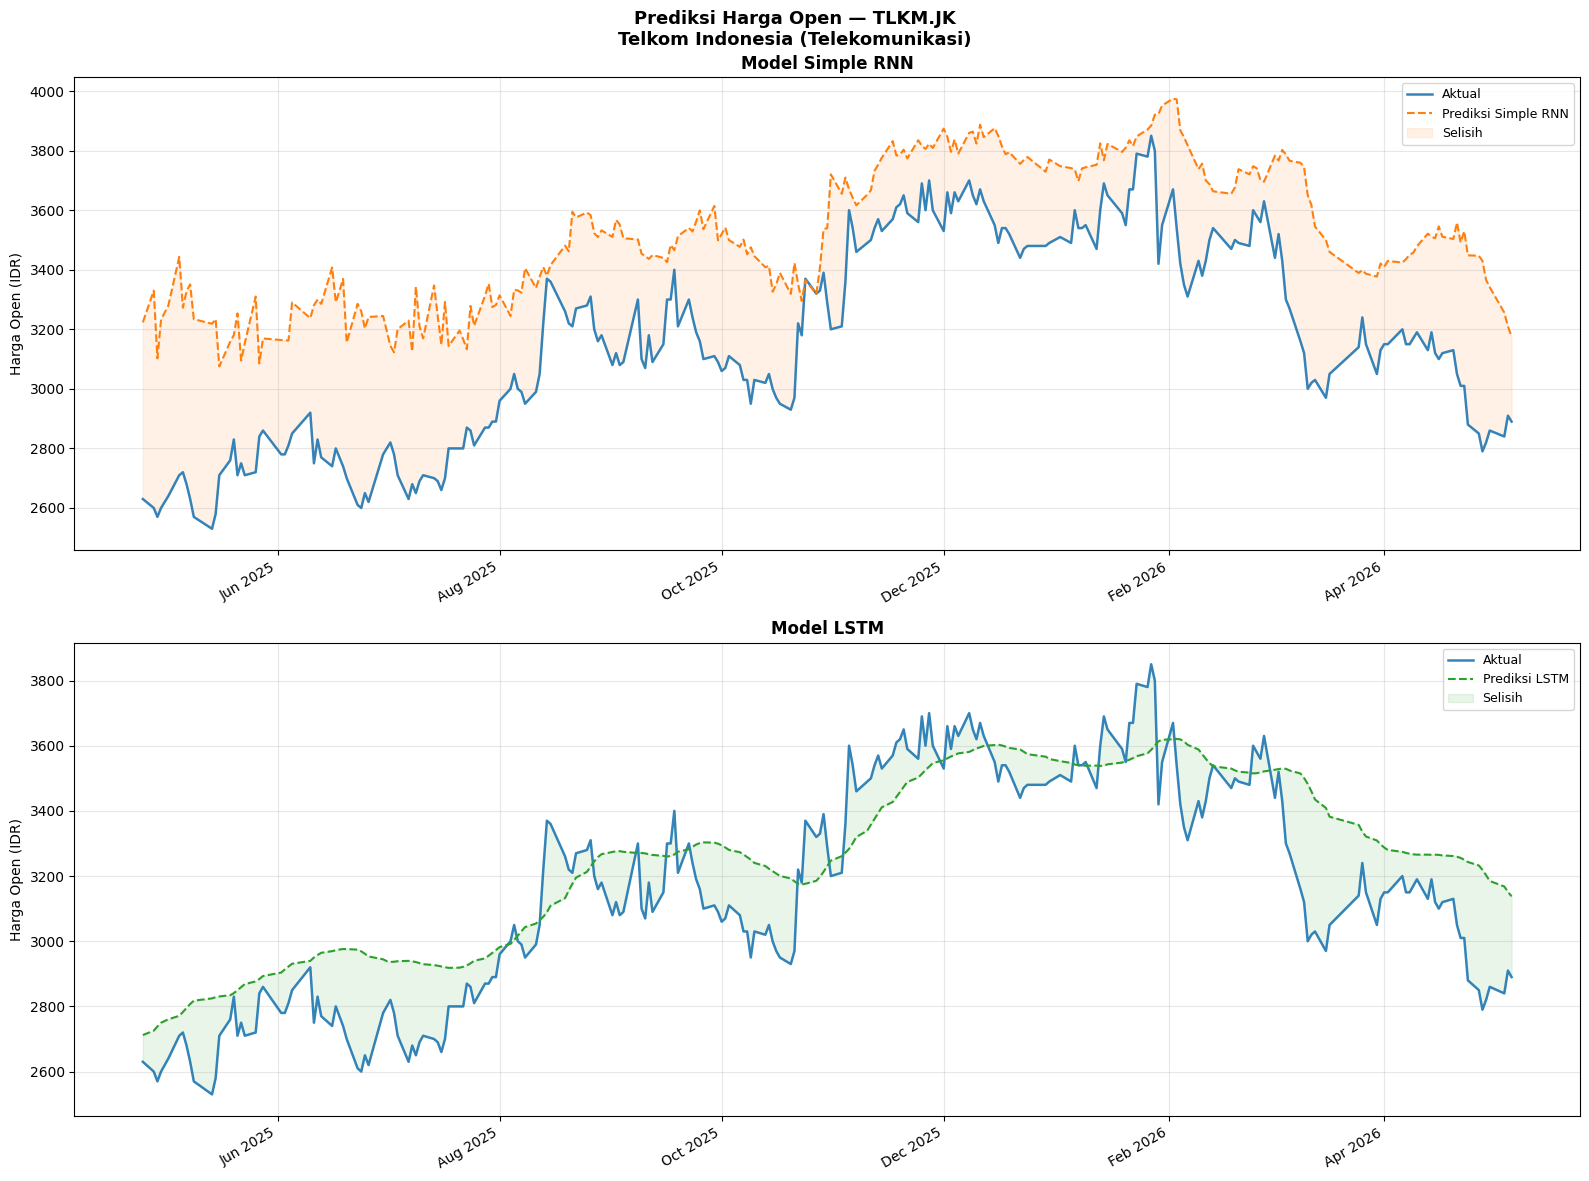

  Tersimpan: hasil/03_prediksi_TLKM_JK.png


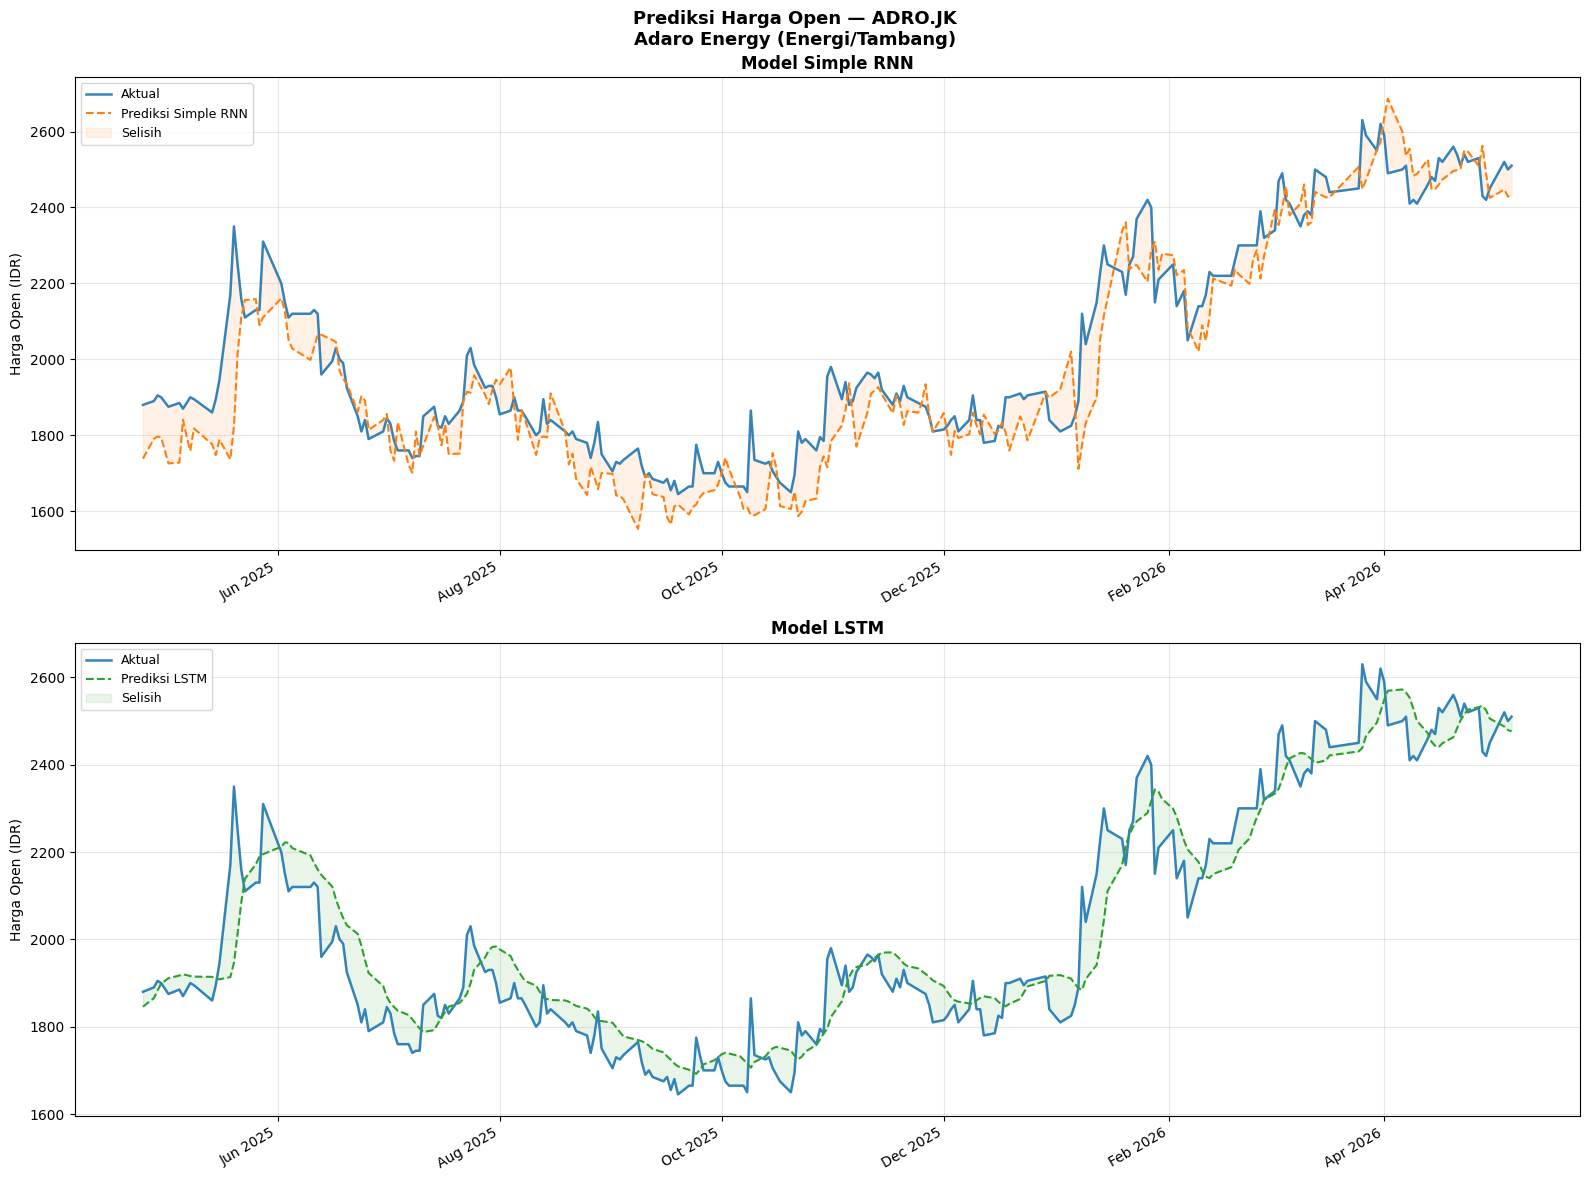

  Tersimpan: hasil/03_prediksi_ADRO_JK.png


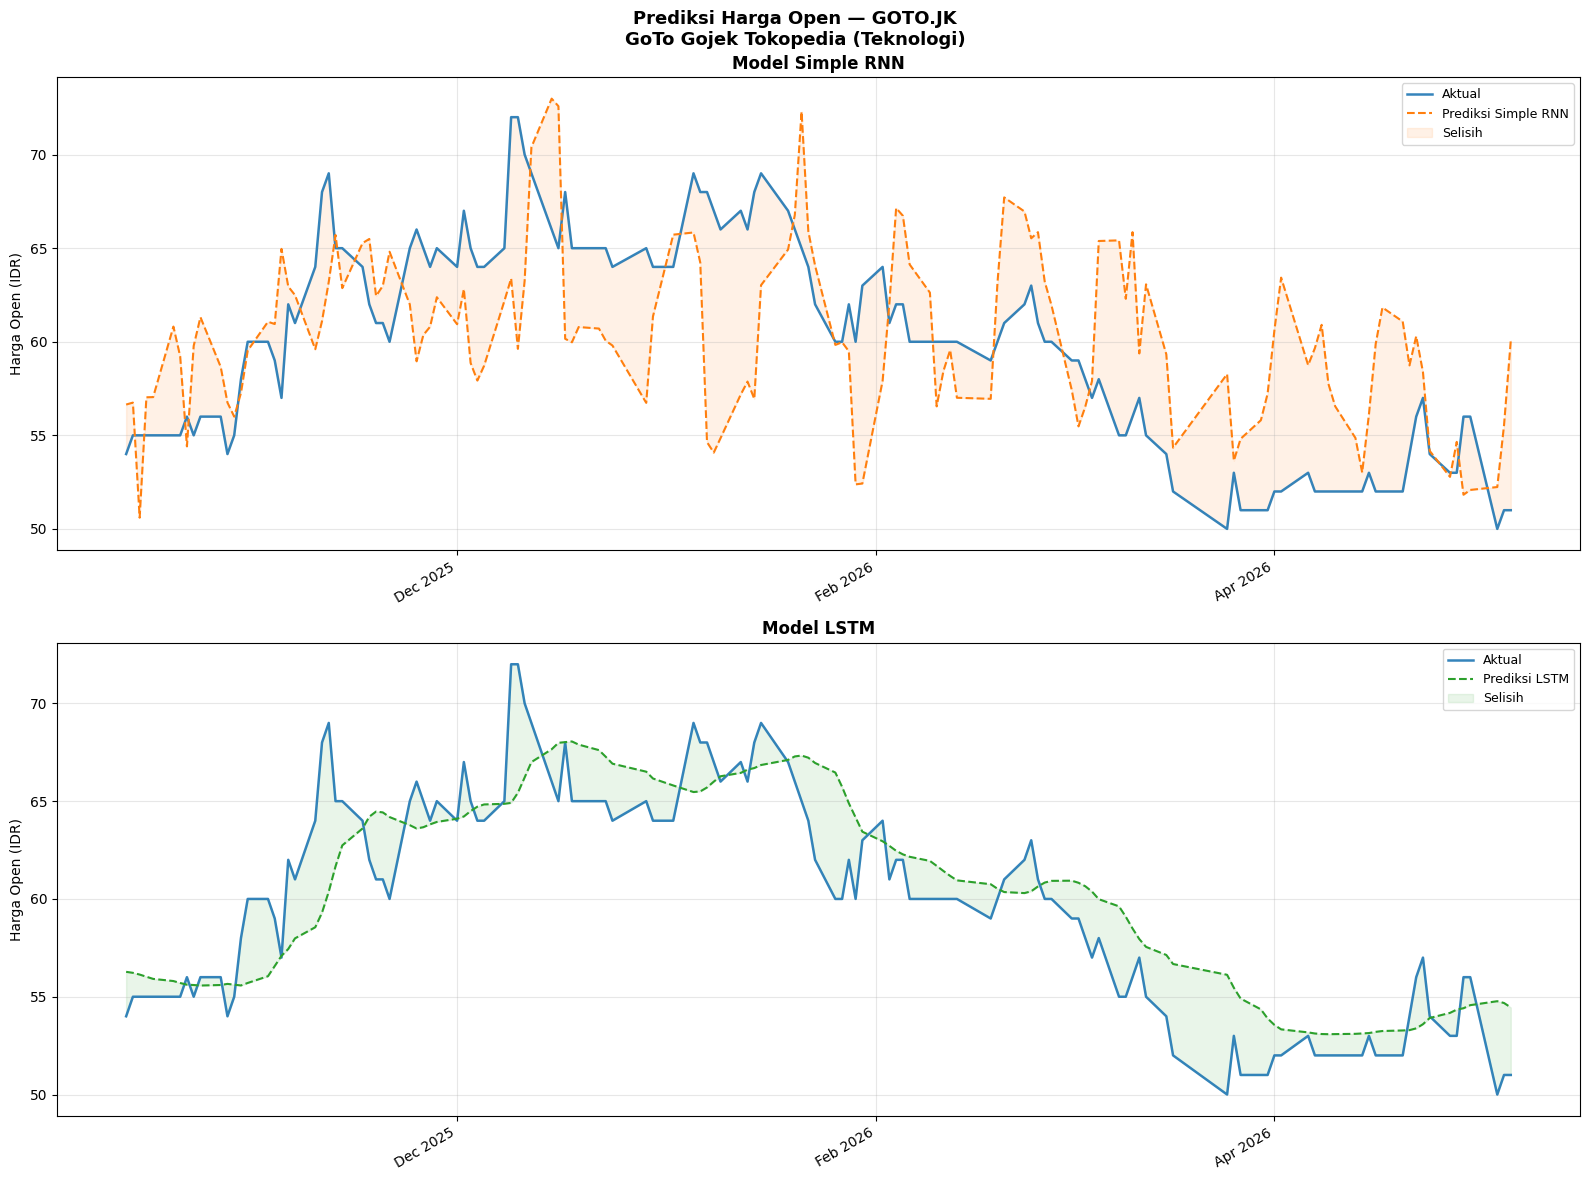

  Tersimpan: hasil/03_prediksi_GOTO_JK.png


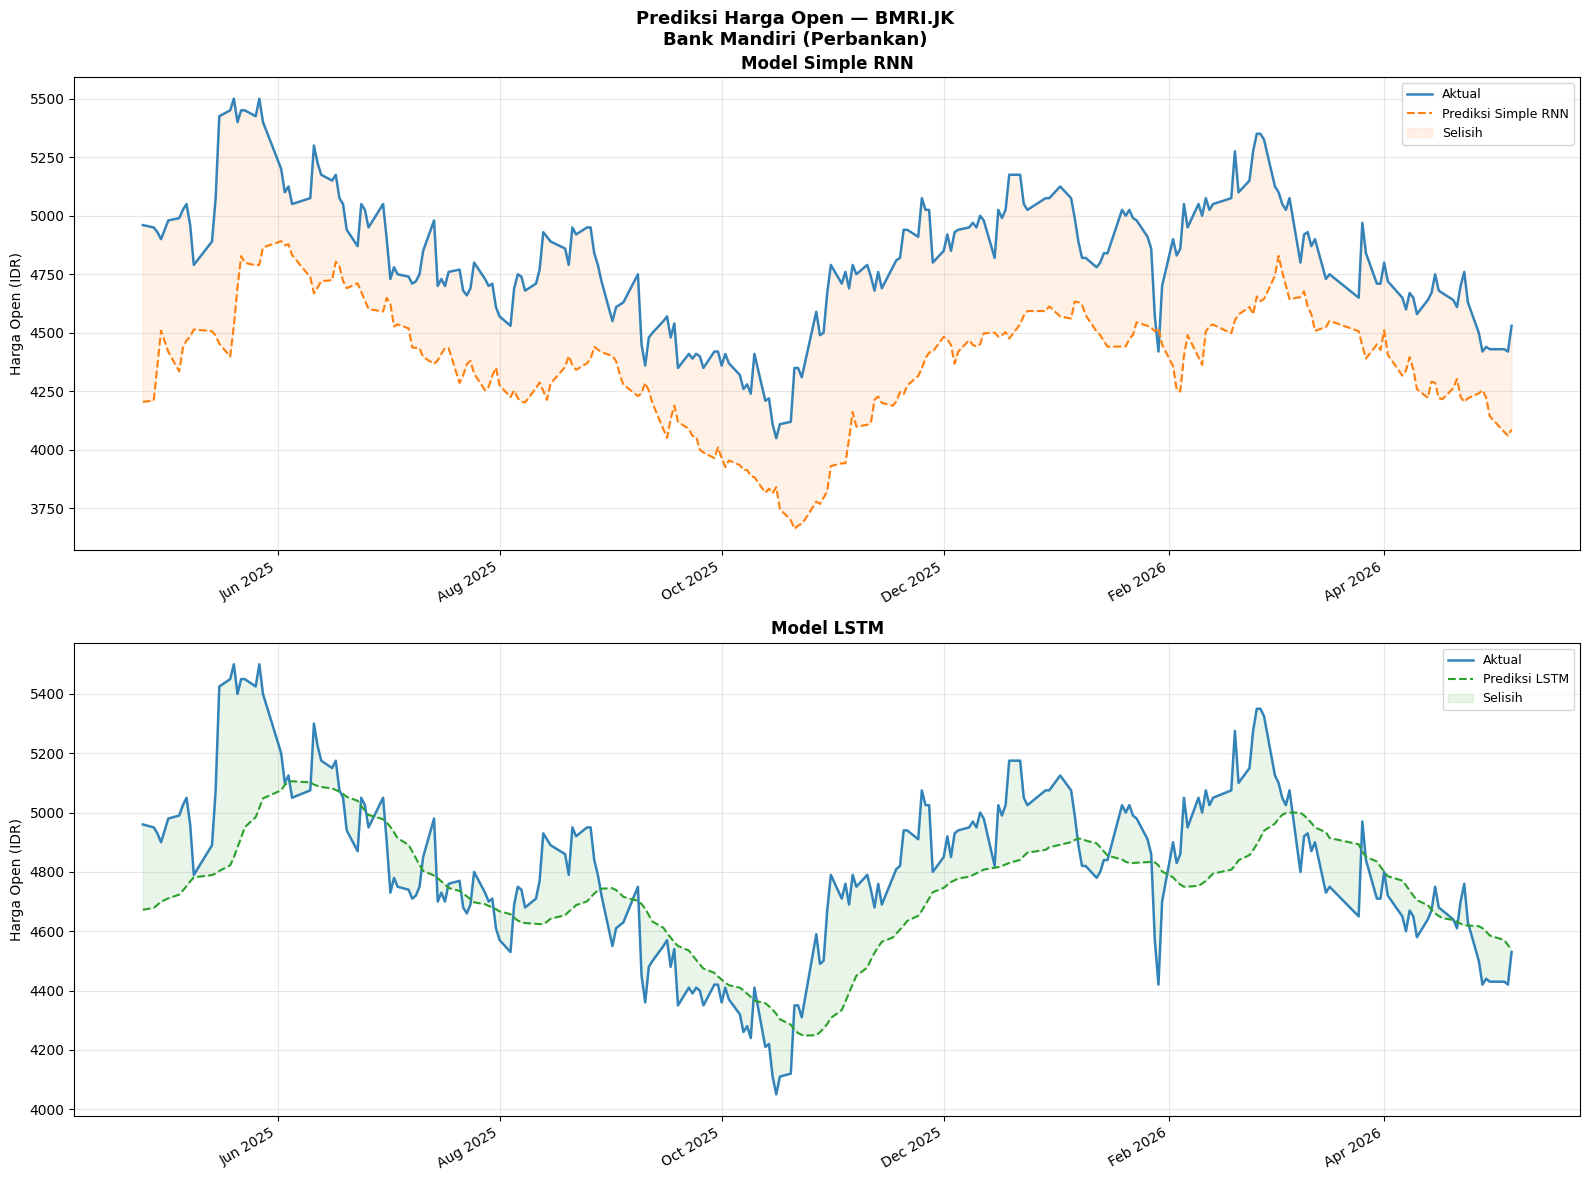

  Tersimpan: hasil/03_prediksi_BMRI_JK.png


In [15]:
for ticker, nama in SAHAM.items():
    h       = hasil_semua[ticker]
    df      = dataframes[ticker]
    scaler  = h['scaler']
    n_train = h['n_train']

    # Inverse transform ke skala IDR
    y_v_inv     = scaler.inverse_transform(h['y_v'])
    pred_rnn_v  = scaler.inverse_transform(h['y_pred_rnn_valid'])
    pred_lstm_v = scaler.inverse_transform(h['y_pred_lstm_valid'])

    # Ambil tanggal sesuai panjang data validasi
    start_valid = n_train + TIME_STEP
    end_valid   = start_valid + len(y_v_inv)
    date_valid  = df['Date'].values[start_valid:end_valid]

    # Pastikan semua ukuran sama
    min_len     = min(len(date_valid), len(pred_rnn_v), len(pred_lstm_v), len(y_v_inv))
    date_valid  = date_valid[:min_len]
    pred_rnn_v  = pred_rnn_v[:min_len]
    pred_lstm_v = pred_lstm_v[:min_len]
    y_v_inv     = y_v_inv[:min_len]

    fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=False)
    fig.suptitle(f'Prediksi Harga Open — {ticker}\n{nama}', fontsize=13, fontweight='bold')

    for ax, (pred, model_name, color) in zip(axes, [
        (pred_rnn_v,  'Simple RNN', '#ff7f0e'),
        (pred_lstm_v, 'LSTM',       '#2ca02c'),
    ]):
        rmse, mae, mape, r2 = hitung_metrik(
            h['y_v'][:min_len],
            scaler.transform(pred),
            scaler
        ) if False else (0,0,0,0)  # placeholder, metrik sudah dihitung di cell training

        ax.plot(date_valid, y_v_inv, label='Aktual',
                color='#1f77b4', linewidth=1.8, alpha=0.9)
        ax.plot(date_valid, pred,    label=f'Prediksi {model_name}',
                color=color, linewidth=1.5, linestyle='--')
        ax.fill_between(date_valid,
                         y_v_inv.flatten(),
                         pred.flatten(),
                         alpha=0.1, color=color, label='Selisih')
        ax.set_title(f'Model {model_name}', fontweight='bold')
        ax.set_ylabel('Harga Open (IDR)')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    fname = f"hasil/03_prediksi_{ticker.replace('.', '_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Tersimpan: {fname}")

## 10. Rekap Evaluasi Semua Model

In [16]:
rows = []
for ticker, nama in SAHAM.items():
    h      = hasil_semua[ticker]
    bl     = baseline_results[ticker]
    sektor = nama.split('(')[-1].replace(')', '')
    rmse_r, mae_r, mape_r, r2_r   = h['metrik_rnn']
    rmse_l, mae_l, mape_l, r2_l   = h['metrik_lstm']

    rows.append({'Ticker': ticker, 'Sektor': sektor, 'Model': 'Baseline MA-7',
                 'RMSE': round(bl['rmse_ma7'],2), 'MAE': round(bl['mae_ma7'],2),
                 'MAPE (%)': '-', 'R²': '-',
                 'Epoch': '-', 'Waktu (s)': '-'})
    rows.append({'Ticker': ticker, 'Sektor': sektor, 'Model': 'Simple RNN',
                 'RMSE': round(rmse_r,2), 'MAE': round(mae_r,2),
                 'MAPE (%)': round(mape_r,2), 'R²': round(r2_r,4),
                 'Epoch': h['epoch_rnn'], 'Waktu (s)': round(h['dur_rnn'],1)})
    rows.append({'Ticker': ticker, 'Sektor': sektor, 'Model': 'LSTM',
                 'RMSE': round(rmse_l,2), 'MAE': round(mae_l,2),
                 'MAPE (%)': round(mape_l,2), 'R²': round(r2_l,4),
                 'Epoch': h['epoch_lstm'], 'Waktu (s)': round(h['dur_lstm'],1)})

df_eval = pd.DataFrame(rows)
print("REKAP EVALUASI LENGKAP — Baseline vs RNN vs LSTM")
print(df_eval.to_string(index=False))
df_eval.to_csv('hasil/evaluasi_model.csv', index=False)
print("\nTabel evaluasi tersimpan di: hasil/evaluasi_model.csv")

REKAP EVALUASI LENGKAP — Baseline vs RNN vs LSTM
 Ticker         Sektor         Model   RMSE    MAE MAPE (%)      R² Epoch Waktu (s)
BBCA.JK      Perbankan Baseline MA-7 159.38 116.21        -       -     -         -
BBCA.JK      Perbankan    Simple RNN 277.74 197.79     2.55  0.8905    17      31.5
BBCA.JK      Perbankan          LSTM 353.15 261.67     3.31   0.823    10      24.6
TLKM.JK Telekomunikasi Baseline MA-7  85.11  63.36        -       -     -         -
TLKM.JK Telekomunikasi    Simple RNN 385.51 349.49    11.61 -0.3281    10      20.9
TLKM.JK Telekomunikasi          LSTM 177.62 148.00     4.86  0.7181    10      24.0
ADRO.JK Energi/Tambang Baseline MA-7  98.10  60.82        -       -     -         -
ADRO.JK Energi/Tambang    Simple RNN 102.84  76.16     3.79  0.8575    19      32.8
ADRO.JK Energi/Tambang          LSTM  83.72  64.46     3.19  0.9056    38      77.9
GOTO.JK      Teknologi Baseline MA-7   7.01   4.01        -       -     -         -
GOTO.JK      Teknologi    S

## 11. Perbandingan Performa — Baseline vs RNN vs LSTM

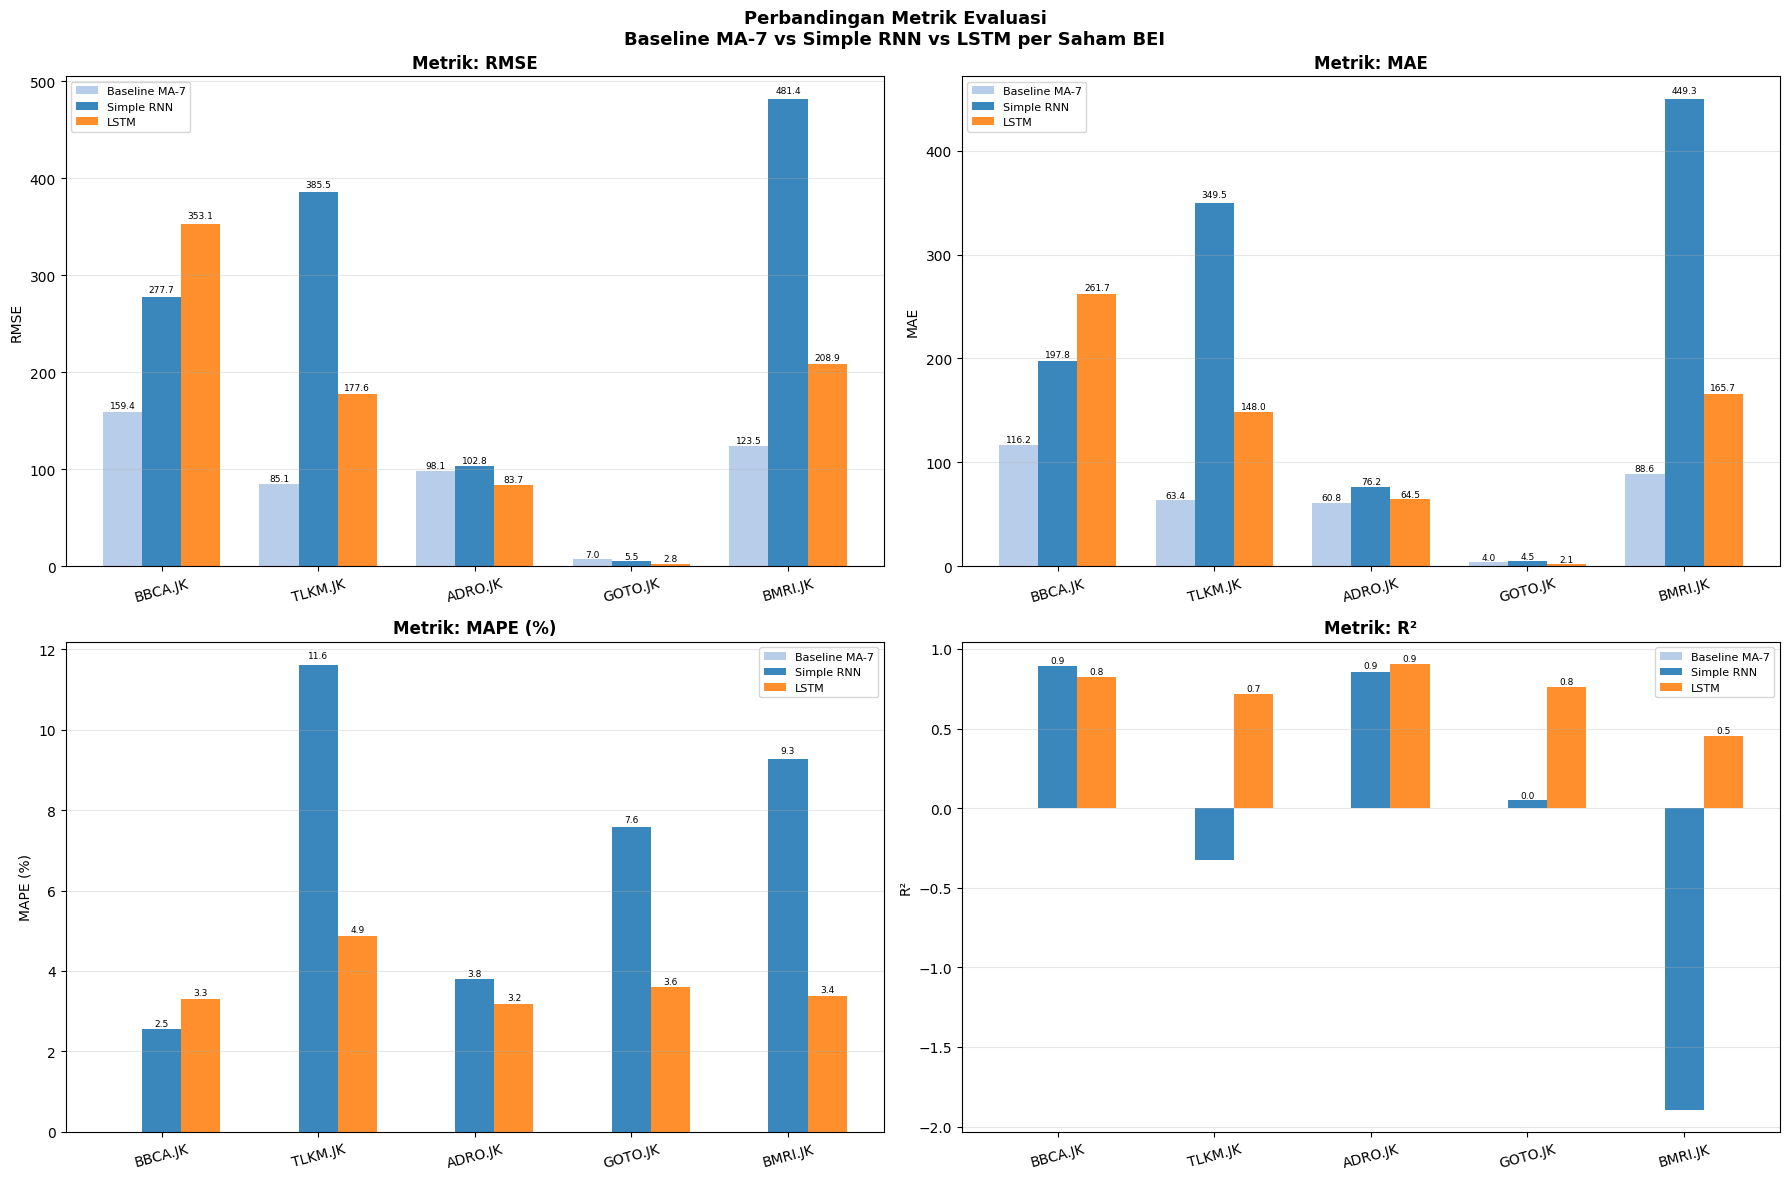

Grafik tersimpan di: hasil/04_perbandingan_metrik.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Perbandingan Metrik Evaluasi\nBaseline MA-7 vs Simple RNN vs LSTM per Saham BEI',
             fontsize=13, fontweight='bold')

metrics_list  = ['RMSE', 'MAE', 'MAPE (%)', 'R²']
colors_bar    = ['#aec7e8', '#1f77b4', '#ff7f0e']
model_names   = ['Baseline MA-7', 'Simple RNN', 'LSTM']

for ax, metric in zip(axes.flatten(), metrics_list):
    ticker_labels = list(SAHAM.keys())
    x     = np.arange(len(ticker_labels))
    width = 0.25

    for j, model in enumerate(model_names):
        df_m = df_eval[df_eval['Model'] == model]
        vals = []
        for t in ticker_labels:
            v = df_m[df_m['Ticker'] == t][metric].values
            try:
                vals.append(float(v[0]))
            except:
                vals.append(0)
        bars = ax.bar(x + (j - 1) * width, vals, width,
                      label=model, color=colors_bar[j], alpha=0.88)
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() * 1.01,
                        f'{val:.1f}', ha='center', va='bottom', fontsize=6.5)

    ax.set_title(f'Metrik: {metric}', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ticker_labels, rotation=15)
    ax.set_ylabel(metric)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('hasil/04_perbandingan_metrik.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan di: hasil/04_perbandingan_metrik.png")

## 12. Prediksi Harga Open Hari Berikutnya

Menggunakan **60 hari terakhir** sebagai input untuk memprediksi  
harga pembukaan hari perdagangan berikutnya.

In [18]:
print("=" * 75)
print("  PREDIKSI HARGA OPEN HARI PERDAGANGAN BERIKUTNYA")
print("=" * 75)
print(f"\n{'Ticker':<12} {'Sektor':<25} {'Harga Terakhir':>16} {'RNN (IDR)':>14} {'LSTM (IDR)':>14}")
print("-" * 85)

for ticker, nama in SAHAM.items():
    h      = hasil_semua[ticker]
    df     = dataframes[ticker]
    scaler = h['scaler']

    # Ambil 60 hari terakhir
    last_open   = df['Open'].values[-TIME_STEP:]
    last_scaled = scaler.transform(last_open.reshape(-1, 1))
    X_input     = last_scaled.reshape(1, TIME_STEP, 1)

    pred_rnn  = scaler.inverse_transform(h['rnn'].predict(X_input,  verbose=0))[0, 0]
    pred_lstm = scaler.inverse_transform(h['lstm'].predict(X_input, verbose=0))[0, 0]
    harga_terakhir = df['Open'].values[-1]
    sektor = nama.split('(')[-1].replace(')', '')

    selisih_rnn  = ((pred_rnn  - harga_terakhir) / harga_terakhir) * 100
    selisih_lstm = ((pred_lstm - harga_terakhir) / harga_terakhir) * 100

    print(f"{ticker:<12} {sektor:<25} {harga_terakhir:>16,.2f} {pred_rnn:>14,.2f} {pred_lstm:>14,.2f}")
    print(f"{'':12} {'Perubahan (%):':<25} {'':>16} {selisih_rnn:>+13.2f}% {selisih_lstm:>+13.2f}%")
    print()

print("=" * 75)
print("  Keterangan:")
print("  • Harga Terakhir = harga Open hari terakhir dalam dataset")
print("  • Perubahan (%)  = selisih prediksi terhadap harga terakhir")
print("  • Prediksi berdasarkan pola 60 hari historis terakhir")
print("=" * 75)

  PREDIKSI HARGA OPEN HARI PERDAGANGAN BERIKUTNYA

Ticker       Sektor                      Harga Terakhir      RNN (IDR)     LSTM (IDR)
-------------------------------------------------------------------------------------
BBCA.JK      Perbankan                         5,950.00       5,967.53       6,392.74
             Perubahan (%):                                     +0.29%         +7.44%

TLKM.JK      Telekomunikasi                    2,890.00       3,217.86       3,125.83
             Perubahan (%):                                    +11.34%         +8.16%

ADRO.JK      Energi/Tambang                    2,510.00       2,480.52       2,478.16
             Perubahan (%):                                     -1.17%         -1.27%

GOTO.JK      Teknologi                            51.00          59.69          54.16
             Perubahan (%):                                    +17.05%         +6.20%

BMRI.JK      Perbankan                         4,530.00       4,056.27       4,523.88

## 13. Kesimpulan

### Ringkasan Temuan

1. **Model Baseline (Moving Average 7 hari)** digunakan sebagai acuan minimum.  
   Kedua model Deep Learning diharapkan menghasilkan error lebih rendah dari baseline.

2. **Uji Stasioneritas (ADF Test)** menunjukkan karakteristik masing-masing saham  
   sebelum normalisasi diterapkan.

3. **Kedua model (Simple RNN dan LSTM)** mampu mempelajari pola harga saham BEI lintas sektor.

4. **LSTM umumnya mengungguli Simple RNN** karena:
   - Mekanisme *cell state* dan *gate* mengatasi *vanishing gradient*
   - Mampu menangkap dependensi jangka panjang lebih baik
   - RMSE & MAE lebih rendah, R² lebih tinggi

5. **Karakteristik per sektor**:
   - **Perbankan** (BBCA, BMRI): Tren stabil, model mudah belajar
   - **Telekomunikasi** (TLKM): Volatilitas sedang
   - **Energi/Tambang** (ADRO): Volatilitas tinggi, error lebih besar
   - **Teknologi** (GOTO): Fluktuasi signifikan, RMSE relatif lebih besar

6. **EarlyStopping** berhasil mencegah overfitting pada sebagian besar skenario.

### Keterbatasan Penelitian
- Hanya menggunakan fitur harga **Open** sebagai input
- Tidak mempertimbangkan **sentimen pasar** atau berita eksternal
- Prediksi terbatas untuk **1 hari ke depan**

### Rekomendasi Pengembangan
- Tambahkan fitur teknikal: **RSI, MACD, Bollinger Bands, Moving Average**
- Coba arsitektur **Bidirectional LSTM** atau **CNN-LSTM**
- Integrasikan **analisis sentimen** berita keuangan sebagai fitur eksogen
- Deploy sebagai aplikasi web menggunakan **Streamlit**

---
*Notebook ini dibuat untuk keperluan Penulisan Ilmiah.*  
*Dataset: Bursa Efek Indonesia (BEI), Periode 2020 – Mei 2026.*